<a href="https://colab.research.google.com/github/gon311/my-university-study/blob/main/%ED%8C%8C%EB%8D%B0%ED%84%B0_12_13%EA%B0%95_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B3%91%ED%95%A9_%EB%B0%8F_%EB%B3%80%ED%99%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 데이터 정저 - 데이터 병합 및 변환

## 데이터의 자료형
    연산 가능성, 속도, 메모리 효율에 직접적으로 영향을 줌
    올바른 분석과 오류 검출의 출발점



1) 자료형 변환의 필요성

- 데이터의 형식에 처리 방식이 종속됨
- 메모리 효율성
- 처리 속도에 영향 미침



2) Pandas를 이용하여 자료형 변환
> 실습 데이터 : travel-times

In [ ]:
import pandas as pd

# sample set download
# url = 'https://openmv.net/file/travel-times.csv'
df = pd.read_csv('/content/travel-times.csv')

print(df.head(10))
print(df.dtypes)

         Date StartTime  DayOfWeek GoingTo  Distance  MaxSpeed  AvgSpeed  \
0    1/6/2012     16:37     Friday    Home     51.29     127.4      78.3   
1    1/6/2012     08:20     Friday     GSK     51.63     130.3      81.8   
2    1/4/2012     16:17  Wednesday    Home     51.27     127.4      82.0   
3    1/4/2012     07:53  Wednesday     GSK     49.17     132.3      74.2   
4    1/3/2012     18:57    Tuesday    Home     51.15     136.2      83.4   
5    1/3/2012     07:57    Tuesday     GSK     51.80     135.8      84.5   
6    1/2/2012     17:31     Monday    Home     51.37     123.2      82.9   
7    1/2/2012     07:34     Monday     GSK     49.01     128.3      77.5   
8  12/23/2011     08:01     Friday     GSK     52.91     130.3      80.9   
9  12/22/2011     17:19   Thursday    Home     51.17     122.3      70.6   

   AvgMovingSpeed FuelEconomy  TotalTime  MovingTime Take407All Comments  
0            84.8         NaN       39.3        36.3         No      NaN  
1            

Pandas의 형변환 함수 사용

    DataFrame.astype() : 범주형 변환에 유용
    Pandas.to_numeric()
    Pandas.to_datetime() : 날짜 - 시간형
    Pandas.to_timedelta() : 시간 길이로 변환
    

In [ ]:
# df['FuelEconomy'] = pd.to_numeric(df['FuelEconomy'])
## Unable to parse string "-" => 이 부분을 체크. 도메인 지식을 이용, 결측치로 변환(NaN) 결정
print(df['FuelEconomy'].unique()[:5]) # NOTE : .uniqur() 중복되지 않는 값 찾기

[nan '-' '8.89' '9.08' '9.76']


Pandas.to_numeric() 에서 errors 파라미터를 이용, 형 변환시 문제 해결

    errors = raise (변환 실패 시 예외 발생)
    errors = coerce (변환 실패 시 NaN 강제 변환)

❗무작정 coerc로 바꾸지 않도록 주의

In [ ]:
import numpy as np

# df['FuelEconomy'] = df['FuelEconomy'].replace('-', np.nan)
df['FuelEconomy'] = pd.to_numeric(df['FuelEconomy'], errors = 'coerce')

print(df['FuelEconomy'].head(10))
print('FeulEconomy Type : ', df['FuelEconomy'].dtype)

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8    8.89
9    8.89
Name: FuelEconomy, dtype: float64
FeulEconomy Type :  float64


In [ ]:
# Date 열 -> datatime
df['Date'] = pd.to_datetime(df['Date'])
#print(df['Date'].head())

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

print(df.head())

        Date StartTime  DayOfWeek GoingTo  Distance  MaxSpeed  AvgSpeed  \
0 2012-01-06     16:37     Friday    Home     51.29     127.4      78.3   
1 2012-01-06     08:20     Friday     GSK     51.63     130.3      81.8   
2 2012-01-04     16:17  Wednesday    Home     51.27     127.4      82.0   
3 2012-01-04     07:53  Wednesday     GSK     49.17     132.3      74.2   
4 2012-01-03     18:57    Tuesday    Home     51.15     136.2      83.4   

   AvgMovingSpeed  FuelEconomy  TotalTime  MovingTime Take407All Comments  \
0            84.8          NaN       39.3        36.3         No      NaN   
1            88.9          NaN       37.9        34.9         No      NaN   
2            85.8          NaN       37.5        35.9         No      NaN   
3            82.9          NaN       39.8        35.6         No      NaN   
4            88.1          NaN       36.8        34.8         No      NaN   

   Year  Month  
0  2012      1  
1  2012      1  
2  2012      1  
3  2012      1  
4

In [ ]:
# DayOfWeek 열을 범주형으로 변환

df['DayOfWeek'] = df['DayOfWeek'].astype('category')

print(df.dtypes)
print(df['DayOfWeek'].head())

Date              datetime64[ns]
StartTime                 object
DayOfWeek               category
GoingTo                   object
Distance                 float64
MaxSpeed                 float64
AvgSpeed                 float64
AvgMovingSpeed           float64
FuelEconomy              float64
TotalTime                float64
MovingTime               float64
Take407All                object
Comments                  object
Year                       int32
Month                      int32
dtype: object
0       Friday
1       Friday
2    Wednesday
3    Wednesday
4      Tuesday
Name: DayOfWeek, dtype: category
Categories (5, object): ['Friday', 'Monday', 'Thursday', 'Tuesday', 'Wednesday']


In [ ]:
# StartTime -> datetime
df['StartTime'] = pd.to_datetime(df['StartTime'])
print(df.dtypes)

Date              datetime64[ns]
StartTime         datetime64[ns]
DayOfWeek               category
GoingTo                   object
Distance                 float64
MaxSpeed                 float64
AvgSpeed                 float64
AvgMovingSpeed           float64
FuelEconomy              float64
TotalTime                float64
MovingTime               float64
Take407All                object
Comments                  object
Year                       int32
Month                      int32
dtype: object


/tmp/ipykernel_12468/4002400040.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['StartTime'] = pd.to_datetime(df['StartTime'])


In [ ]:
# GoingTo -> category
df['GoingTo'] = df['GoingTo'].astype('category')
print(df.dtypes)

Date              datetime64[ns]
StartTime         datetime64[ns]
DayOfWeek               category
GoingTo                 category
Distance                 float64
MaxSpeed                 float64
AvgSpeed                 float64
AvgMovingSpeed           float64
FuelEconomy              float64
TotalTime                float64
MovingTime               float64
Take407All                object
Comments                  object
Year                       int32
Month                      int32
dtype: object


In [ ]:
# Take407All -> bool
#df['Take407All'].unique()

df['Take407All_bool'] = df['Take407All'].map({'Yes': True, 'No': False})
df['Take407All_bool'] = df['Take407All_bool'].astype('bool')


print(df.dtypes)
print(df.head(10))


Date               datetime64[ns]
StartTime          datetime64[ns]
DayOfWeek                category
GoingTo                  category
Distance                  float64
MaxSpeed                  float64
AvgSpeed                  float64
AvgMovingSpeed            float64
FuelEconomy               float64
TotalTime                 float64
MovingTime                float64
Take407All                 object
Comments                   object
Year                        int32
Month                       int32
Take407All_bool              bool
dtype: object
        Date           StartTime  DayOfWeek GoingTo  Distance  MaxSpeed  \
0 2012-01-06 2026-04-28 16:37:00     Friday    Home     51.29     127.4   
1 2012-01-06 2026-04-28 08:20:00     Friday     GSK     51.63     130.3   
2 2012-01-04 2026-04-28 16:17:00  Wednesday    Home     51.27     127.4   
3 2012-01-04 2026-04-28 07:53:00  Wednesday     GSK     49.17     132.3   
4 2012-01-03 2026-04-28 18:57:00    Tuesday    Home     51.15     1

In [ ]:
# format 매개변수 사용
df_example = pd.DataFrame({
    'date_str' : ['2025-04-01', '2025-04-02', '2025-04-03']
})

df_example['date'] = pd.to_datetime(df_example['date_str'], format='%Y-%m-%d')

print(df_example)

     date_str       date
0  2025-04-01 2025-04-01
1  2025-04-02 2025-04-02
2  2025-04-03 2025-04-03


3) 데이터 병합

- 데이터 연결(concatenation) : 단순 종적 연결

    기본적으로 합집합 연산

주의점

    새로운 행을 concat으로 연결할 경우, 자료형이 바뀔 수 있으므로, 데이터를 연결하기 전에 미리 자료형을 변형해야함.

In [ ]:
# 새로운 운행 기록 한 행 (dictionary로 생성)
new_trip = {
    'Date': '1/11/2012',
    'StartTime': '08:10',
    'DayOfWeek': 'Wednesday',
    'GoingTo': 'GSK',
    'Distance': 50.0,
    'MaxSpeed': 126.0,
    'AvgSpeed': 78.0,
    'AvgMovingSpeed': 82.0,
    'FuelEconomy': 7.9,
    'TotalTime': 42.0,
    'MovingTime': 40.0,
    'Take407All': 'No',
    'Comments': ''
}

new_df = pd.DataFrame([new_trip])

# 기존 df + new_df : 확장된 데이터프레임 제작
df_extended = pd.concat([df, new_df], ignore_index = True)

print(df_extended.tail(5))
print("연결 후 행 개수: ", len(df_extended))
print(df_extended.dtypes)

                    Date            StartTime  DayOfWeek GoingTo  Distance  \
201  2011-07-14 00:00:00  2026-04-28 08:03:00   Thursday     GSK     50.90   
202  2011-07-13 00:00:00  2026-04-28 17:08:00  Wednesday    Home     51.96   
203  2011-07-12 00:00:00  2026-04-28 17:51:00    Tuesday    Home     53.28   
204  2011-07-11 00:00:00  2026-04-28 16:56:00     Monday    Home     51.73   
205            1/11/2012                08:10  Wednesday     GSK     50.00   

     MaxSpeed  AvgSpeed  AvgMovingSpeed  FuelEconomy  TotalTime  MovingTime  \
201     123.7      76.2            95.1         7.89       40.1        32.1   
202     132.6      57.5            76.7          NaN       54.2        40.6   
203     125.8      61.6            87.6          NaN       51.9        36.5   
204     125.0      62.8            92.5          NaN       49.5        33.6   
205     126.0      78.0            82.0         7.90       42.0        40.0   

    Take407All Comments    Year  Month Take407All_bool  

In [ ]:
# 목적지에 대한 추가 정보 데이터프레임
dest_info = pd.DataFrame({
    'GoingTo' : ['Home', 'GSK', 'Cafe'],
    'DestinationType' : ['Residence', 'Workplace', 'Other'],
    'Code' : [1, 2, 3]
})

print(dest_info)

  GoingTo DestinationType  Code
0    Home       Residence     1
1     GSK       Workplace     2
2    Cafe           Other     3


In [ ]:
df_merged = pd.merge(df, dest_info, on="GoingTo", how="inner")
print(df_merged.head())
print(len(df_merged))  # NOTE : 205 ;

        Date           StartTime  DayOfWeek GoingTo  Distance  MaxSpeed  \
0 2012-01-06 2026-04-28 16:37:00     Friday    Home     51.29     127.4   
1 2012-01-06 2026-04-28 08:20:00     Friday     GSK     51.63     130.3   
2 2012-01-04 2026-04-28 16:17:00  Wednesday    Home     51.27     127.4   
3 2012-01-04 2026-04-28 07:53:00  Wednesday     GSK     49.17     132.3   
4 2012-01-03 2026-04-28 18:57:00    Tuesday    Home     51.15     136.2   

   AvgSpeed  AvgMovingSpeed  FuelEconomy  TotalTime  MovingTime Take407All  \
0      78.3            84.8          NaN       39.3        36.3         No   
1      81.8            88.9          NaN       37.9        34.9         No   
2      82.0            85.8          NaN       37.5        35.9         No   
3      74.2            82.9          NaN       39.8        35.6         No   
4      83.4            88.1          NaN       36.8        34.8         No   

  Comments  Year  Month  Take407All_bool DestinationType  Code  
0      NaN  201

In [ ]:
df_merged = pd.merge(df, dest_info, on="GoingTo", how="left")
print(df_merged.head())
print(len(df_merged))  # NOTE : 205 ;

        Date           StartTime  DayOfWeek GoingTo  Distance  MaxSpeed  \
0 2012-01-06 2026-04-28 16:37:00     Friday    Home     51.29     127.4   
1 2012-01-06 2026-04-28 08:20:00     Friday     GSK     51.63     130.3   
2 2012-01-04 2026-04-28 16:17:00  Wednesday    Home     51.27     127.4   
3 2012-01-04 2026-04-28 07:53:00  Wednesday     GSK     49.17     132.3   
4 2012-01-03 2026-04-28 18:57:00    Tuesday    Home     51.15     136.2   

   AvgSpeed  AvgMovingSpeed  FuelEconomy  TotalTime  MovingTime Take407All  \
0      78.3            84.8          NaN       39.3        36.3         No   
1      81.8            88.9          NaN       37.9        34.9         No   
2      82.0            85.8          NaN       37.5        35.9         No   
3      74.2            82.9          NaN       39.8        35.6         No   
4      83.4            88.1          NaN       36.8        34.8         No   

  Comments  Year  Month  Take407All_bool DestinationType  Code  
0      NaN  201

In [ ]:
df_merged = pd.merge(df, dest_info, on="GoingTo", how="right")
print(df_merged.tail())
print(len(df_merged))  # NOTE : 206 ;

          Date           StartTime  DayOfWeek GoingTo  Distance  MaxSpeed  \
201 2011-07-20 2026-04-28 08:24:00  Wednesday     GSK     48.50     125.8   
202 2011-07-19 2026-04-28 08:11:00    Tuesday     GSK     50.96     124.3   
203 2011-07-18 2026-04-28 08:09:00     Monday     GSK     54.52     125.6   
204 2011-07-14 2026-04-28 08:03:00   Thursday     GSK     50.90     123.7   
205        NaT                 NaT        NaN    Cafe       NaN       NaN   

     AvgSpeed  AvgMovingSpeed  FuelEconomy  TotalTime  MovingTime Take407All  \
201      75.7            87.3         7.89       38.5        33.3        Yes   
202      82.3            96.4         7.89       37.2        31.7        Yes   
203      49.9            82.4         7.89       65.5        39.7         No   
204      76.2            95.1         7.89       40.1        32.1        Yes   
205       NaN             NaN          NaN        NaN         NaN        NaN   

    Comments    Year  Month Take407All_bool DestinationT

In [ ]:
df_merged = pd.merge(df, dest_info, on="GoingTo", how="outer")
print(df_merged.head())
print(len(df_merged))  # NOTE : 206 ;

        Date           StartTime  DayOfWeek GoingTo  Distance  MaxSpeed  \
0        NaT                 NaT        NaN    Cafe       NaN       NaN   
1 2012-01-06 2026-04-28 08:20:00     Friday     GSK     51.63     130.3   
2 2012-01-04 2026-04-28 07:53:00  Wednesday     GSK     49.17     132.3   
3 2012-01-03 2026-04-28 07:57:00    Tuesday     GSK     51.80     135.8   
4 2012-01-02 2026-04-28 07:34:00     Monday     GSK     49.01     128.3   

   AvgSpeed  AvgMovingSpeed  FuelEconomy  TotalTime  MovingTime Take407All  \
0       NaN             NaN          NaN        NaN         NaN        NaN   
1      81.8            88.9          NaN       37.9        34.9         No   
2      74.2            82.9          NaN       39.8        35.6         No   
3      84.5            88.8          NaN       36.8        35.0         No   
4      77.5            85.9          NaN       37.9        34.3         No   

  Comments    Year  Month Take407All_bool DestinationType  Code  
0      NaN    

변수 단위와 범위 차이는 거리, 마진, 규제항 계산에 왜곡을 유발한다.

▶ 스케일링이 머신러닝 모델에 어떤 영향을 미치는가

    선형회귀로 모델 학습을 할 경우, 속성별 단위 차이로 인한 오해가 발생할 수 있음.
    ➡ 스케일링이 필요
    - 거리 기반 모델들(필수) : K-최근접 이웃(KNN), K-평균 군집화, DBSCAN, 계층적 군집 분석 등
    - 서포트 벡터 머신(SVM)
    - 가중치 기반 선형 모델들(릿지 회귀, 라쏘 회귀 등 규제항 사용하는 모델들)
    - 신경망 모델 : 입력 차원의 스케일이 크게 차이나는 경우 정규화(학습 효율에 영향)
    - 주성분 분석(PCA) : 분산이 큰 변수일수록 더 큰 영향을 줌

In [ ]:
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression

df = sns.load_dataset('mpg').dropna()

# 두 변수 선택 : 무게, 가속력
X = df[['weight', 'acceleration']]
y = df['mpg']

# 회귀 모델 학습
model = LinearRegression().fit(X, y)

# 회귀 계수 확인
print('스케일링 전 계수: ', dict(zip(X.columns, model.coef_)))

print(df[['weight', 'acceleration']])

# NOTE : 계수만 봤을 땐 acceleration이 종속변수에 더 많은 영향을 미치는 것 처럼 보임.
# 그러나 weight와 acceleration의 단위 차이에서 발생하는 차이

스케일링 전 계수:  {'weight': np.float64(-0.007293095113825714), 'acceleration': np.float64(0.26165039648878785)}
     weight  acceleration
0      3504          12.0
1      3693          11.5
2      3436          11.0
3      3433          12.0
4      3449          10.5
..      ...           ...
393    2790          15.6
394    2130          24.6
395    2295          11.6
396    2625          18.6
397    2720          19.4

[392 rows x 2 columns]


## 2) 정규화와 표준화


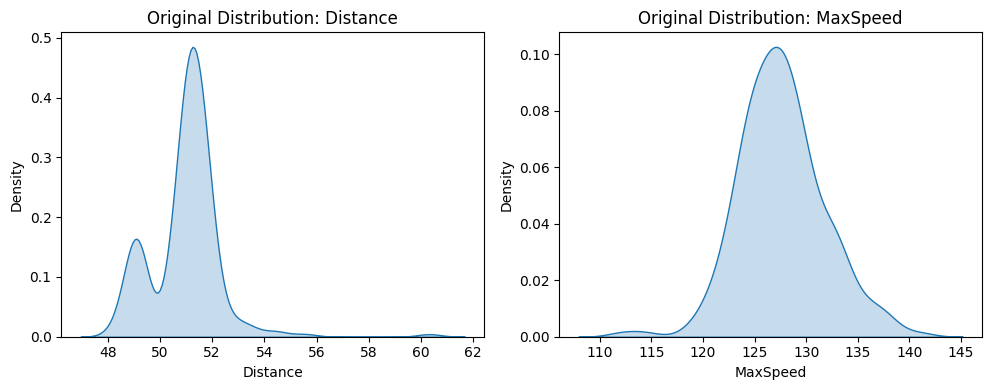

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/travel-times.csv')

# 사용할 변수 선택 / 결측치 제거
features = ['Distance', 'MaxSpeed']
df_selected = df[features].dropna()

#1.  정규화 전 분포 시각화
plt.figure(figsize=(15, 4))
for i, col in enumerate(features):
    plt.subplot(1, 3, i + 1)
    sns.kdeplot(df_selected[col], fill=True)
    plt.title(f'Original Distribution: {col}')

plt.tight_layout()
plt.show()


# 두 변수는 단위 각각 km, km/. 1:3 정도의 스케일 차이 존재

(1) Min-Max 정규화

    최소-최대 범위를 0-1로 변환. 모든 값을 [0,1] 범위로 압축
    이상치에 특히 취약. 이상치 제거 필요.


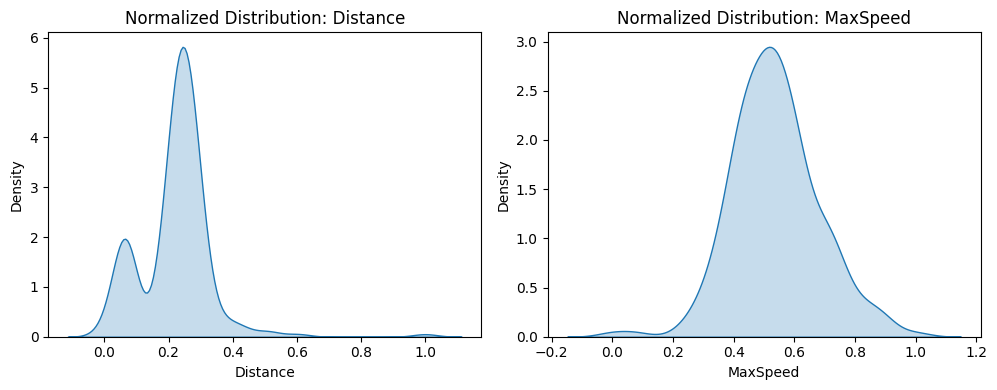

In [ ]:
from sklearn.preprocessing import MinMaxScaler


# 2. Min-Max 정규화 수행
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_selected), columns=features)

# 3. 정규화 후 분포 시각화

plt.figure(figsize=(15,4))
for i, col in enumerate(features):
    plt.subplot(1, 3, i + 1)
    sns.kdeplot(df_scaled[col], fill=True)
    plt.title(f'Normalized Distribution: {col}')

plt.tight_layout()
plt.show()

(2) 표준화(StandardScaler)

    z-변환과 동일

    원본 특성이 정규분포를 따른다는 가정하에 사용한다.
    : 분산이 비슷해지므로,

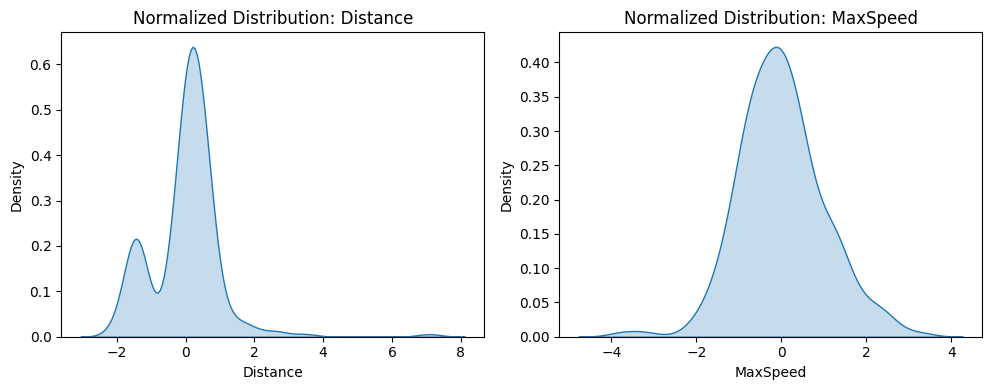

In [ ]:
from sklearn.preprocessing import StandardScaler


# 2. 표준화(StandardScaler) 수행
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_selected), columns=features)

# 3. 정규화 후 분포 시각화

plt.figure(figsize=(15,4))
for i, col in enumerate(features):
    plt.subplot(1, 3, i + 1)
    sns.kdeplot(df_scaled[col], fill=True)
    plt.title(f'Normalized Distribution: {col}')

plt.tight_layout()
plt.show()